# Expresión Génica Diferencial (DGE - DEA) en RNA-Seq

Experimento de 24 cultivos primarios de tumores paratiroideos negativos para receptores de estrógenos alfa (ERα). 

Las muestras, procedentes de 4 pacientes diferentes, se han tratado con dos fármacos diferentes: diarilpropionitrilo (DPN) o 4-hidroxitamoxifeno (OHT) a 24h o 48h. 

El DPN es un agonista del ERα mientras que el OHT es un inhibidor competitivo de los receptores de estrógenos.

- Cultivos primarios: Son células extraídas directamente de tejido tumoral y cultivadas en laboratorio.
- Tumores paratiroideos: Se originan en las glándulas paratiroides, que regulan el calcio mediante la hormona paratiroidea (PTH). Los tumores más comunes son adenomas paratiroideos, asociados con hiperparatiroidismo.
- no tienen receptores de estrógeno alfa (ERα) significa que no producen o no expresan esa proteína en su superficie o dentro de la célula.

In [1]:
# Load required libraries
library(DESeq2)
library(ggplot2)
library(pheatmap)
library(dplyr)
library(RColorBrewer)
library(hexbin)
library(vsn)
library(biomaRt)
library(EnhancedVolcano)

Warning message:
“package ‘DESeq2’ was built under R version 4.4.3”
Cargando paquete requerido: S4Vectors

Warning message:
“package ‘S4Vectors’ was built under R version 4.4.2”
Cargando paquete requerido: stats4

Cargando paquete requerido: BiocGenerics

Warning message:
“package ‘BiocGenerics’ was built under R version 4.4.2”



Adjuntando el paquete: ‘BiocGenerics’


The following objects are masked from ‘package:stats’:

    IQR, mad, sd, var, xtabs


The following objects are masked from ‘package:base’:

    anyDuplicated, aperm, append, as.data.frame, basename, cbind,
    colnames, dirname, do.call, duplicated, eval, evalq, Filter, Find,
    get, grep, grepl, intersect, is.unsorted, lapply, Map, mapply,
    match, mget, order, paste, pmax, pmax.int, pmin, pmin.int,
    Position, rank, rbind, Reduce, rownames, sapply, saveRDS, setdiff,
    table, tapply, union, unique, unsplit, which.max, which.min



Adjuntando el paquete: ‘S4Vectors’


The following object is masked from ‘package:utils’:

    findMatches


The following objects are masked from ‘package:base’:

    expand.grid, I, unname


Cargando paquete requerido: IRanges

Cargando paquete requerido: GenomicRanges

Warning message:
“package ‘GenomicRanges’ was built under R version 4.4.2”
Cargando paquete requerido: GenomeInfoDb

Cargando paquete reque

In [2]:
counts <- read.delim("Apartado2/input/rawcounts.tsv", row.names = 1)
metadata <- read.delim("Apartado2/input/metadata.tsv", row.names = 1)

dimensiones <- dim(counts)
print(paste("Genes:", dimensiones[1], ", Muestras:", dimensiones[2]))

[1] "Genes: 53160 , Muestras: 24"


In [3]:
print("Metadata:")
print(dim(metadata))
print(head(metadata))

[1] "Metadata:"
[1] 24  3
          patient   agent time
GSM913873       1 Control  24h
GSM913874       1 Control  48h
GSM913875       1     DPN  24h
GSM913876       1     DPN  48h
GSM913877       1     OHT  24h
GSM913878       1     OHT  48h


In [4]:
# Encoding
metadata$agent <- factor(metadata$agent)
metadata$time <- factor(metadata$time)
metadata$patient <- factor(metadata$patient)

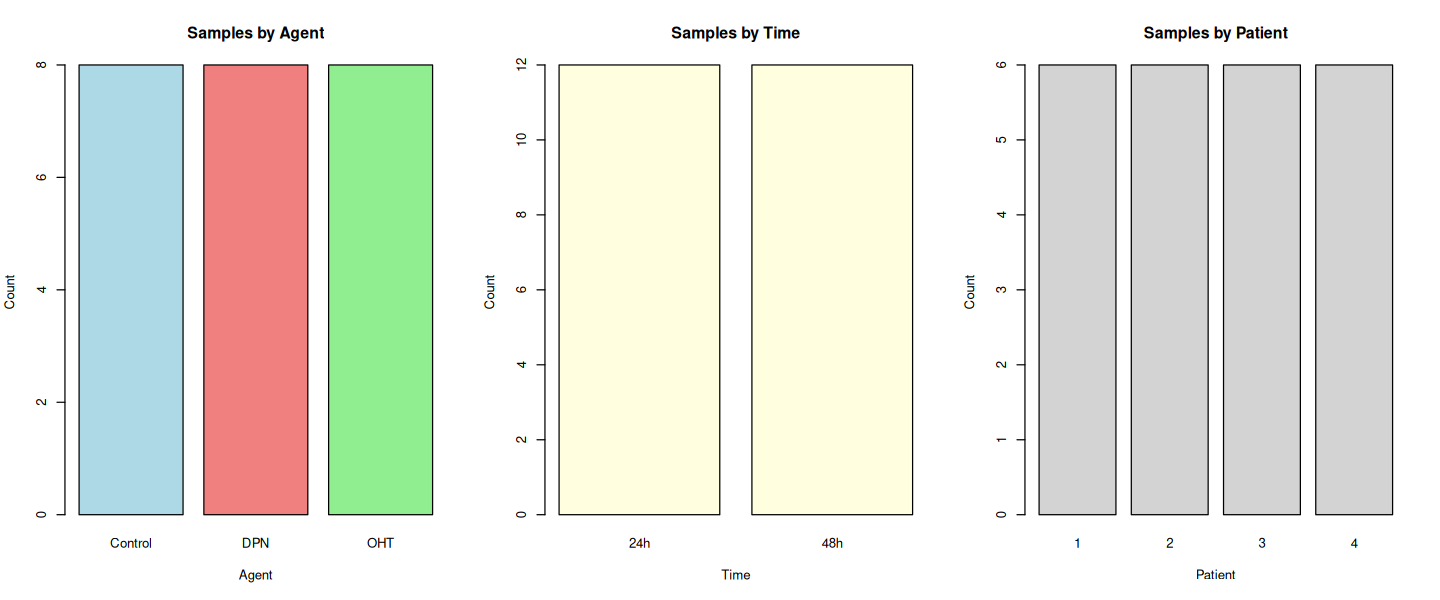

In [5]:
options(repr.plot.width = 12, repr.plot.height = 5)

par(mfrow = c(1, 3), bg = "white")

# Agent distribution
barplot(table(metadata$agent), 
        main = "Samples by Agent", 
        xlab = "Agent", ylab = "Count",
        col = c("lightblue", "lightcoral", "lightgreen"))

# Time distribution
barplot(table(metadata$time), 
        main = "Samples by Time", 
        xlab = "Time", ylab = "Count",
        col = "lightyellow")

# Patient distribution
barplot(table(metadata$patient), 
        main = "Samples by Patient", 
        xlab = "Patient", ylab = "Count",
        col = "lightgray")
options(repr.plot.width = 7, repr.plot.height = 7)

In [6]:
# Pre-filtering: remove genes with very low counts en la matriz counts
print(paste("Genes before:", nrow(counts)))
counts <- counts[rowSums(counts) >= 10, ]
print(paste("Genes after filtering:", nrow(counts)))

[1] "Genes before: 53160"


[1] "Genes after filtering: 24416"


In [7]:
dds <- DESeqDataSetFromMatrix(countData = counts,
                               colData = metadata,
                               design = ~ patient + time + agent)

dds

class: DESeqDataSet 
dim: 24416 24 
metadata(1): version
assays(1): counts
rownames(24416): ENSG00000000003 ENSG00000000005 ... ENSG00000257108
  ENSG00000257112
rowData names(0):
colnames(24): GSM913873 GSM913874 ... GSM913895 GSM913896
colData names(3): patient agent time

In [8]:
# Obtain the gen Symbols
mart <- useMart("ensembl", dataset="hsapiens_gene_ensembl")
genes <- rownames(dds)

gene_map <- getBM(
  attributes=c("ensembl_gene_id","hgnc_symbol"),
  filters="ensembl_gene_id",
  values=genes,
  mart=mart
)

gene_map_matched <- gene_map[match(rownames(dds), gene_map$ensembl_gene_id), ]
head(gene_map_matched)

,ensembl_gene_id,hgnc_symbol
,<chr>,<chr>
1,ENSG00000000003,TSPAN6
2,ENSG00000000005,TNMD
3,ENSG00000000419,DPM1
4,ENSG00000000457,SCYL3
5,ENSG00000000460,FIRRM
6,ENSG00000000938,FGR


In [9]:
gene_labels <- ifelse(
  is.na(gene_map_matched$hgnc_symbol) | gene_map_matched$hgnc_symbol == "",
  rownames(dds),
  gene_map_matched$hgnc_symbol
)
names(gene_labels) <- rownames(dds)
print(head(gene_labels))

ENSG00000000003 ENSG00000000005 ENSG00000000419 ENSG00000000457 ENSG00000000460 
       "TSPAN6"          "TNMD"          "DPM1"         "SCYL3"         "FIRRM" 
ENSG00000000938 
          "FGR" 


In [10]:
rowData(dds)$gene <- gene_labels[rownames(dds)]
dds

class: DESeqDataSet 
dim: 24416 24 
metadata(1): version
assays(1): counts
rownames(24416): ENSG00000000003 ENSG00000000005 ... ENSG00000257108
  ENSG00000257112
rowData names(1): gene
colnames(24): GSM913873 GSM913874 ... GSM913895 GSM913896
colData names(3): patient agent time

In [11]:
# Run DESeq pipeline
dds <- DESeq(dds, test = "Wald")
dds

estimating size factors

estimating dispersions

gene-wise dispersion estimates

mean-dispersion relationship

final dispersion estimates

fitting model and testing



class: DESeqDataSet 
dim: 24416 24 
metadata(1): version
assays(4): counts mu H cooks
rownames(24416): ENSG00000000003 ENSG00000000005 ... ENSG00000257108
  ENSG00000257112
rowData names(43): gene baseMean ... deviance maxCooks
colnames(24): GSM913873 GSM913874 ... GSM913895 GSM913896
colData names(4): patient agent time sizeFactor

# EDA

In [12]:
vst_qc <- vst(dds, blind = TRUE) # Variance Stabilizing Transformation
vst_qc

class: DESeqTransform 
dim: 24416 24 
metadata(1): version
assays(1): ''
rownames(24416): ENSG00000000003 ENSG00000000005 ... ENSG00000257108
  ENSG00000257112
rowData names(43): gene baseMean ... maxCooks dispFit
colnames(24): GSM913873 GSM913874 ... GSM913895 GSM913896
colData names(4): patient agent time sizeFactor

## Descriptive 

In [13]:
norm_counts <- counts(dds, normalized = TRUE)
raw_counts <- counts(dds, normalized = FALSE)

gene_distribution <- data.frame(
  mean = rowMeans(norm_counts),
  median = apply(norm_counts, 1, median),
  variance = apply(norm_counts, 1, var),
  sd = apply(norm_counts, 1, sd),
  min = apply(norm_counts, 1, min),
  max = apply(norm_counts, 1, max),
  zero_fraction = rowMeans(norm_counts == 0)
)

head(gene_distribution)

,mean,median,variance,sd,min,max,zero_fraction
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
ENSG00000000003,561.354460,501.518825,33179.710428,182.152986,351.422286,966.107189,0.000
ENSG00000000005,0.836186,0.000000,2.045836,1.430327,0.000000,4.527198,0.625
ENSG00000000419,244.052822,252.313918,897.598544,29.959949,150.338790,285.121300,0.000
ENSG00000000457,190.404159,181.723354,2096.737907,45.790151,129.873924,268.767597,0.000
ENSG00000000460,344.140157,287.740045,39106.511717,197.753664,108.888023,808.276603,0.000
ENSG00000000938,11.129902,8.655921,64.781615,8.048703,1.779095,35.476125,0.000


In [14]:
summary(gene_distribution)

      mean              median            variance               sd           
 Min.   :    0.17   Min.   :    0.00   Min.   :        0   Min.   :    0.373  
 1st Qu.:    2.95   1st Qu.:    2.23   1st Qu.:        5   1st Qu.:    2.257  
 Median :   50.02   Median :   43.31   Median :      285   Median :   16.877  
 Mean   :  324.29   Mean   :  313.43   Mean   :   166983   Mean   :   88.781  
 3rd Qu.:  326.85   3rd Qu.:  315.99   3rd Qu.:     4813   3rd Qu.:   69.377  
 Max.   :63949.62   Max.   :58249.18   Max.   :770712864   Max.   :27761.716  
      min                max            zero_fraction   
 Min.   :    0.00   Min.   :     1.22   Min.   :0.0000  
 1st Qu.:    0.00   1st Qu.:     8.88   1st Qu.:0.0000  
 Median :   16.46   Median :    96.21   Median :0.0000  
 Mean   :  196.37   Mean   :   516.01   Mean   :0.1326  
 3rd Qu.:  196.74   3rd Qu.:   492.08   3rd Qu.:0.1667  
 Max.   :41791.86   Max.   :113066.94   Max.   :0.8750  

In [15]:
top_mean_genes = head(order(gene_distribution$mean, decreasing = TRUE), 10)
top_mean_genes

[1]  2251 15638 15682  8808 16536 15630 15602  7742  2767 12318

In [16]:
gene_labels[top_mean_genes]

ENSG00000100604 ENSG00000198804 ENSG00000198886 ENSG00000152266 ENSG00000210082 
         "CHGA"        "MT-CO1"        "MT-ND4"           "PTH"       "MT-RNR2" 
ENSG00000198786 ENSG00000198727 ENSG00000143153 ENSG00000104368 ENSG00000173821 
       "MT-ND5"        "MT-CYB"        "ATP1B1"          "PLAT"        "RNF213"

In [17]:
gene_distribution[top_mean_genes, ]

,mean,median,variance,sd,min,max,zero_fraction
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
ENSG00000100604,63949.62,58249.18,333123355,18251.667,41791.861,104741.48,0
ENSG00000198804,47123.64,44251.51,124928054,11177.122,30408.241,67614.34,0
ENSG00000198886,34671.10,31091.18,105766263,10284.273,17415.285,54907.96,0
ENSG00000152266,31823.67,22797.43,770712864,27761.716,4381.523,113066.94,0
ENSG00000210082,30825.01,30138.93,28813036,5367.778,19357.188,42061.36,0
ENSG00000198786,27762.06,25322.91,58617549,7656.210,14741.426,44140.79,0
ENSG00000198727,25499.91,18893.00,175909943,13263.105,11931.702,51589.81,0
ENSG00000143153,23178.92,19934.62,136630743,11688.915,10895.177,49742.15,0
ENSG00000104368,22187.93,17820.50,140515736,11853.933,6102.794,54541.71,0


In [18]:
top_var_genes = head(order(gene_distribution$variance, decreasing = TRUE), 10)
top_var_genes

[1]  8808  2251 15602  2767  7742 15638 15682  5114  7006  9253

In [19]:
gene_labels[top_var_genes]

ENSG00000152266 ENSG00000100604 ENSG00000198727 ENSG00000104368 ENSG00000143153 
          "PTH"          "CHGA"        "MT-CYB"          "PLAT"        "ATP1B1" 
ENSG00000198804 ENSG00000198886 ENSG00000123983 ENSG00000137801 ENSG00000156535 
       "MT-CO1"        "MT-ND4"         "ACSL3"         "THBS1"         "CD109"

In [20]:
gene_distribution[top_var_genes, ]

,mean,median,variance,sd,min,max,zero_fraction
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
ENSG00000152266,31823.675,22797.427,770712864,27761.716,4381.5232,113066.94,0
ENSG00000100604,63949.617,58249.175,333123355,18251.667,41791.8608,104741.48,0
ENSG00000198727,25499.913,18892.998,175909943,13263.105,11931.7022,51589.81,0
ENSG00000104368,22187.930,17820.495,140515736,11853.933,6102.7938,54541.71,0
ENSG00000143153,23178.924,19934.621,136630743,11688.915,10895.1769,49742.15,0
ENSG00000198804,47123.637,44251.510,124928054,11177.122,30408.2409,67614.34,0
ENSG00000198886,34671.101,31091.179,105766263,10284.273,17415.2849,54907.96,0
ENSG00000123983,14213.547,16325.643,85905557,9268.525,3941.4932,37244.54,0
ENSG00000137801,6629.467,2541.231,65395604,8086.755,819.7621,31959.00,0


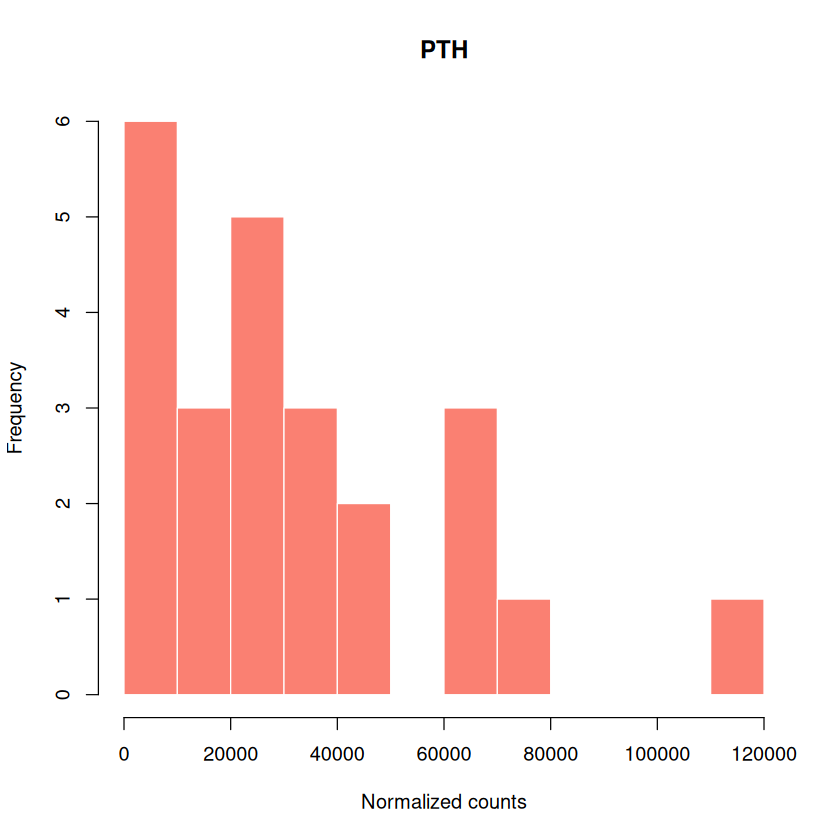

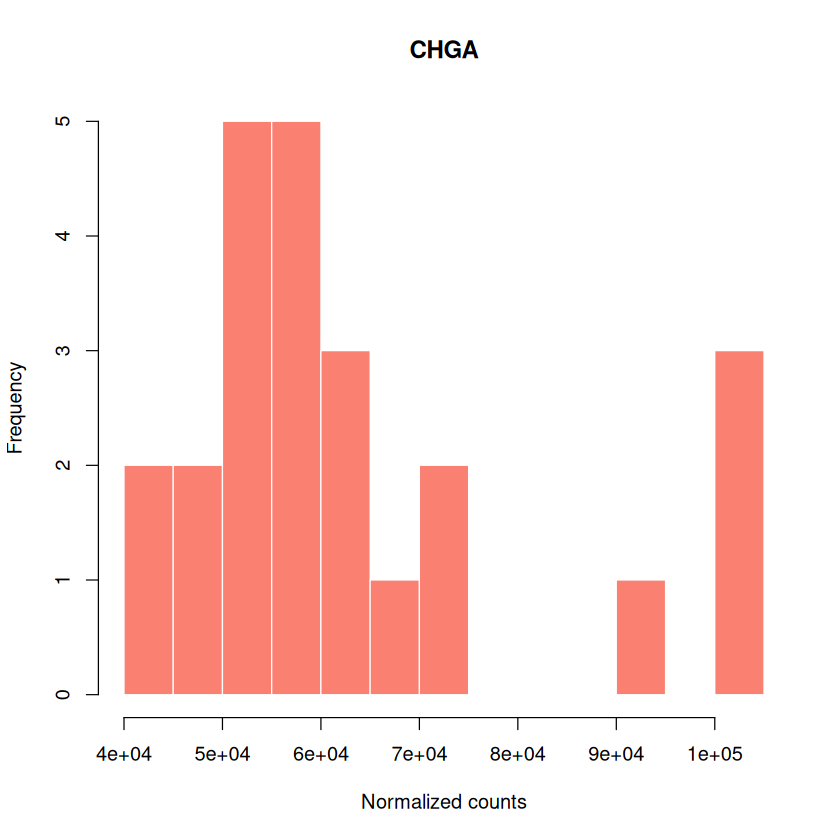

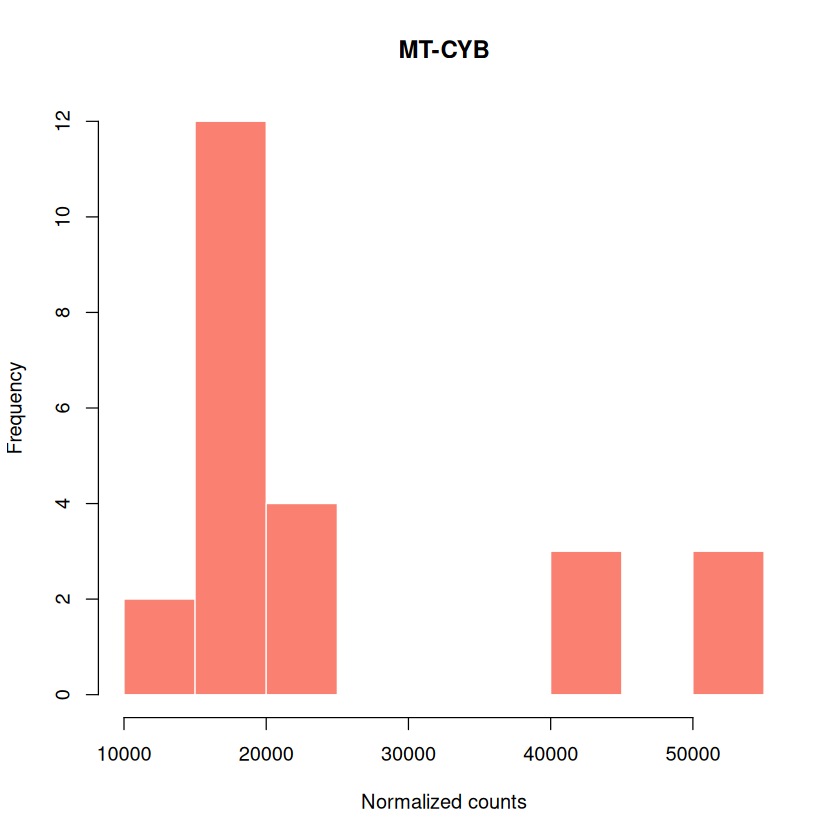

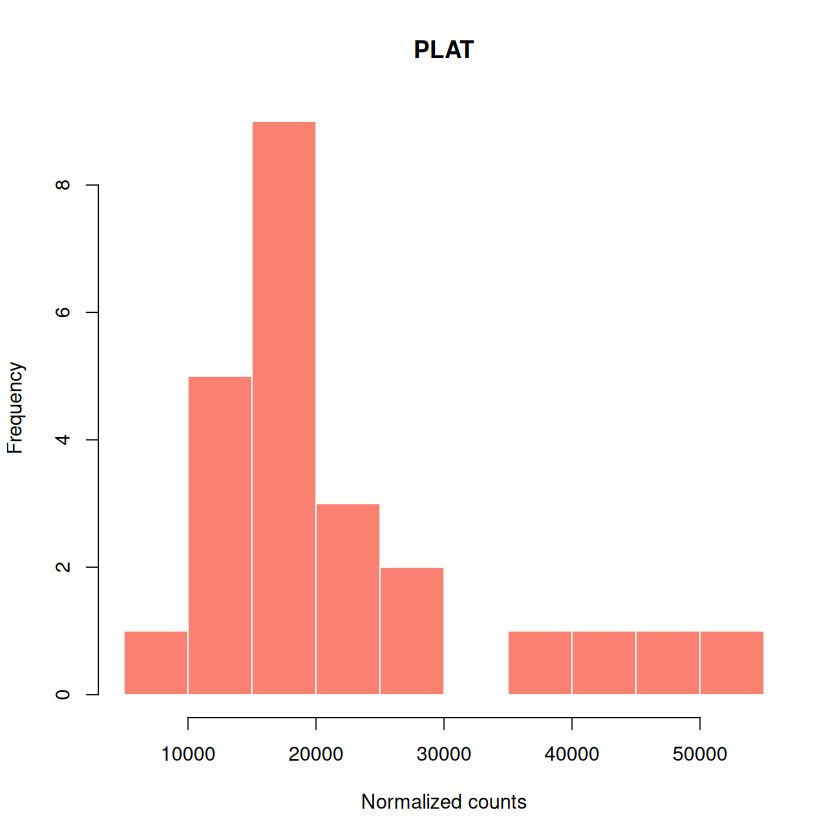

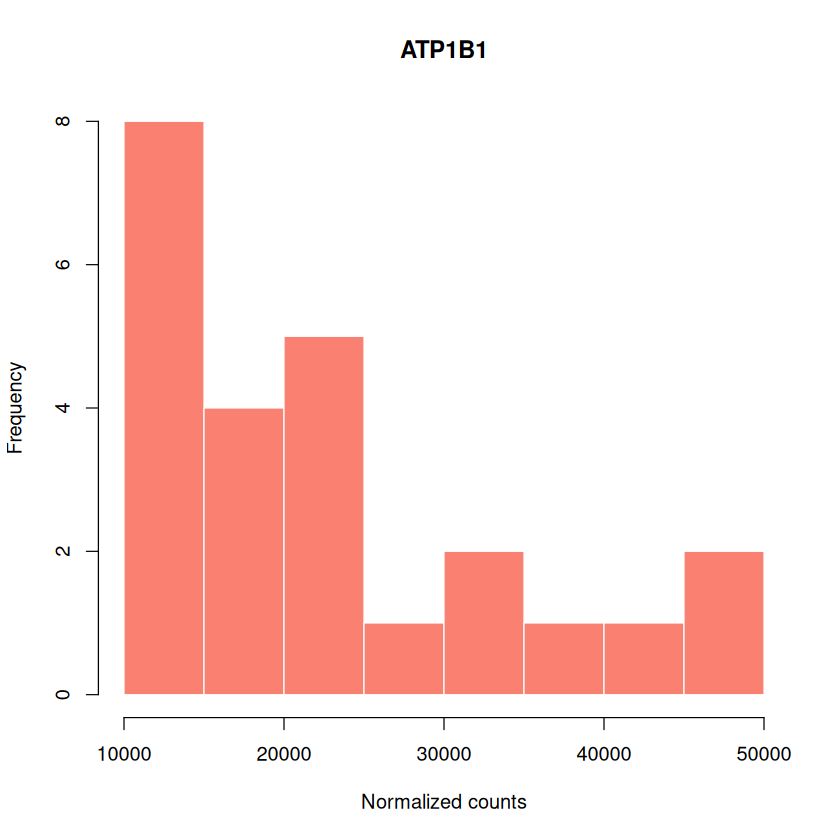

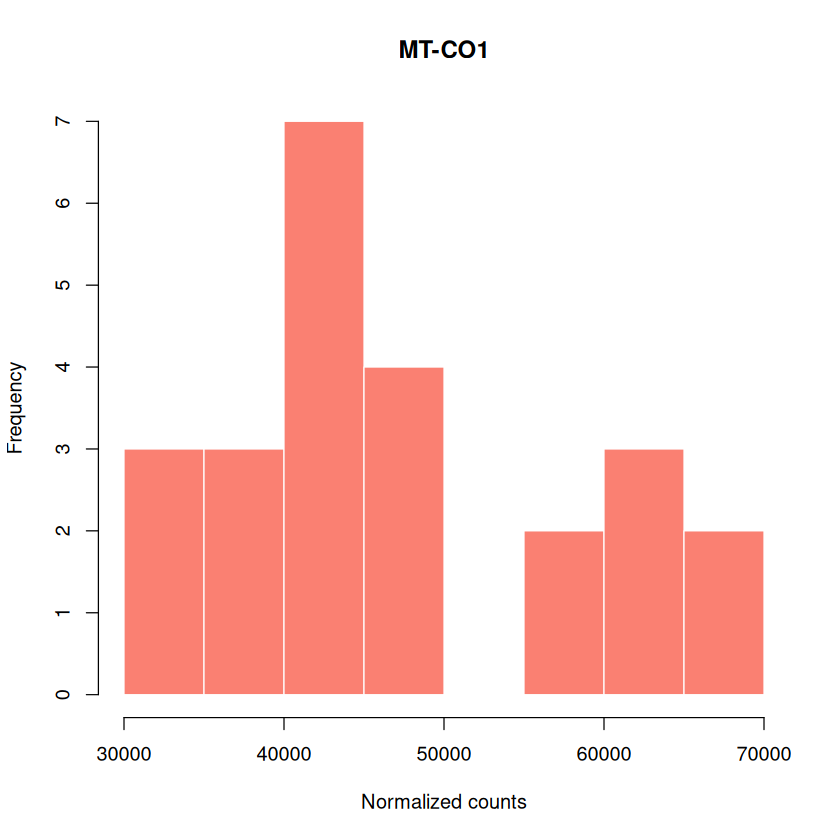

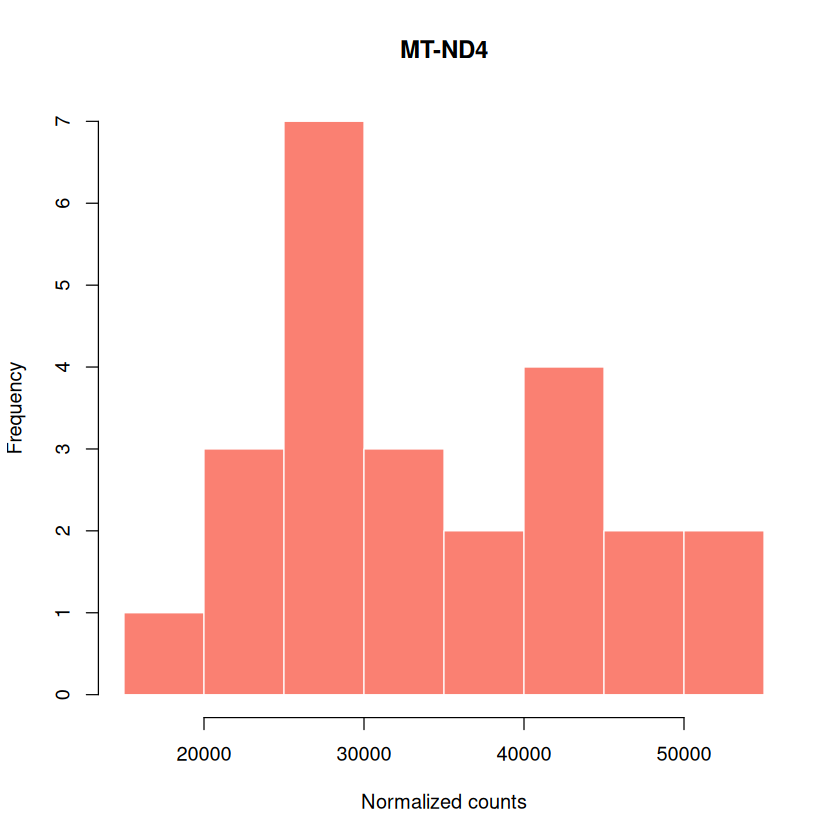

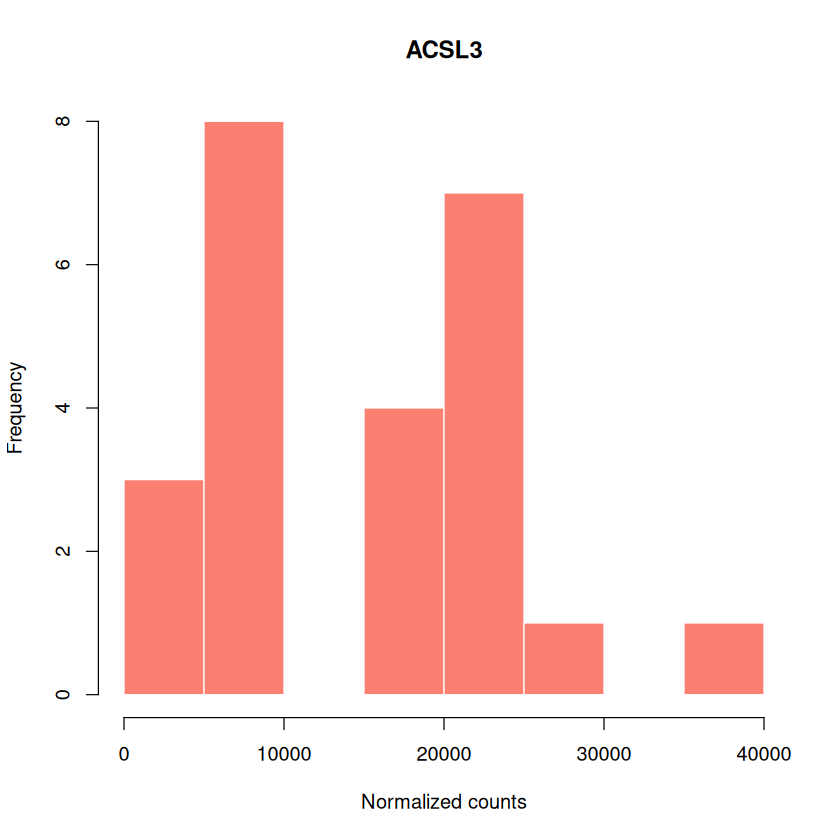

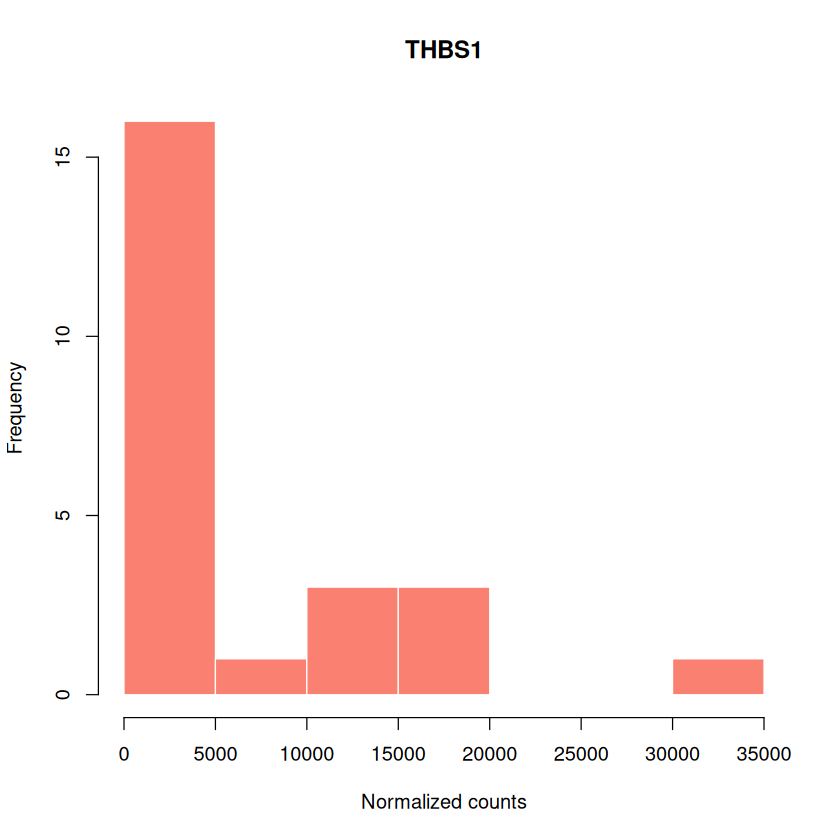

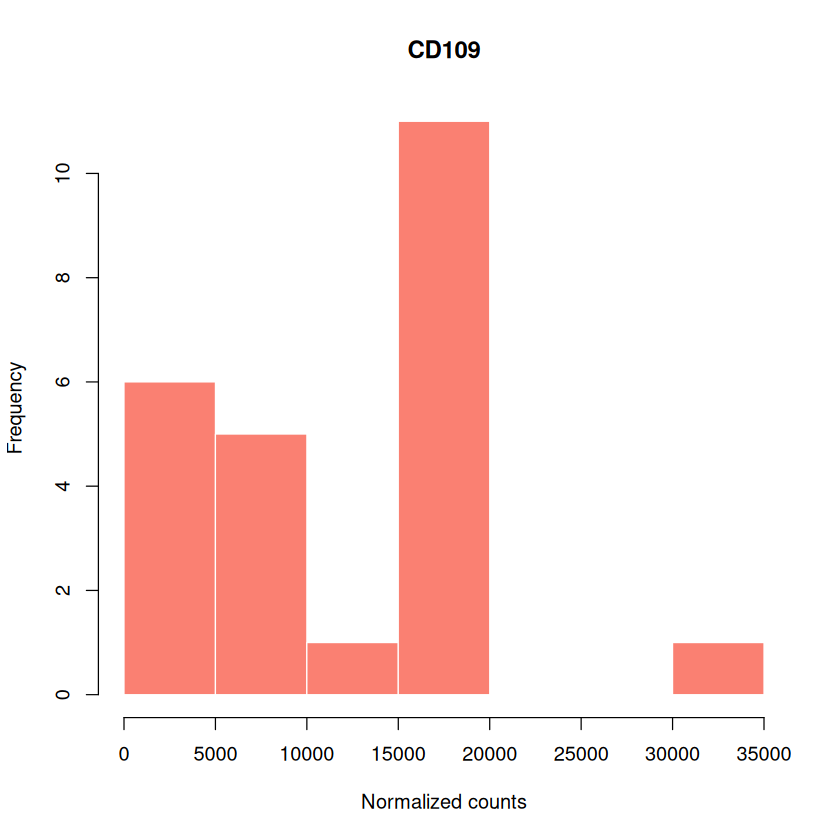

In [21]:
par(bg = "white")

for (i in top_var_genes) {
    hist(norm_counts[i, ],
         breaks = 10,
         main = gene_labels[i],
         xlab = "Normalized counts",
         col = "salmon",
         border = "white")
}
par(mfrow = c(1, 1))

## Batch efect & Outliers

using ntop=500 top features by variance



Warning message:
“`aes_string()` was deprecated in ggplot2 3.0.0.
ℹ Please use tidy evaluation idioms with `aes()`.
ℹ See also `vignette("ggplot2-in-packages")` for more information.
ℹ The deprecated feature was likely used in the DESeq2 package.
  Please report the issue to the authors.”


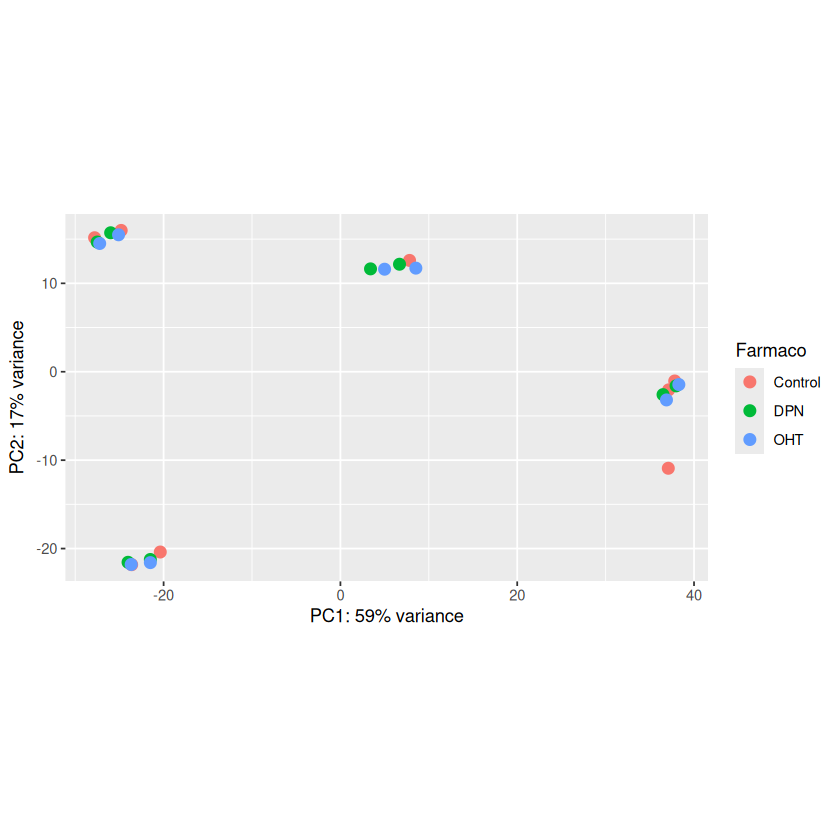

In [22]:
p <- plotPCA(vst_qc, intgroup = "agent", returnData = FALSE)
p + labs(color = "Farmaco")

using ntop=500 top features by variance



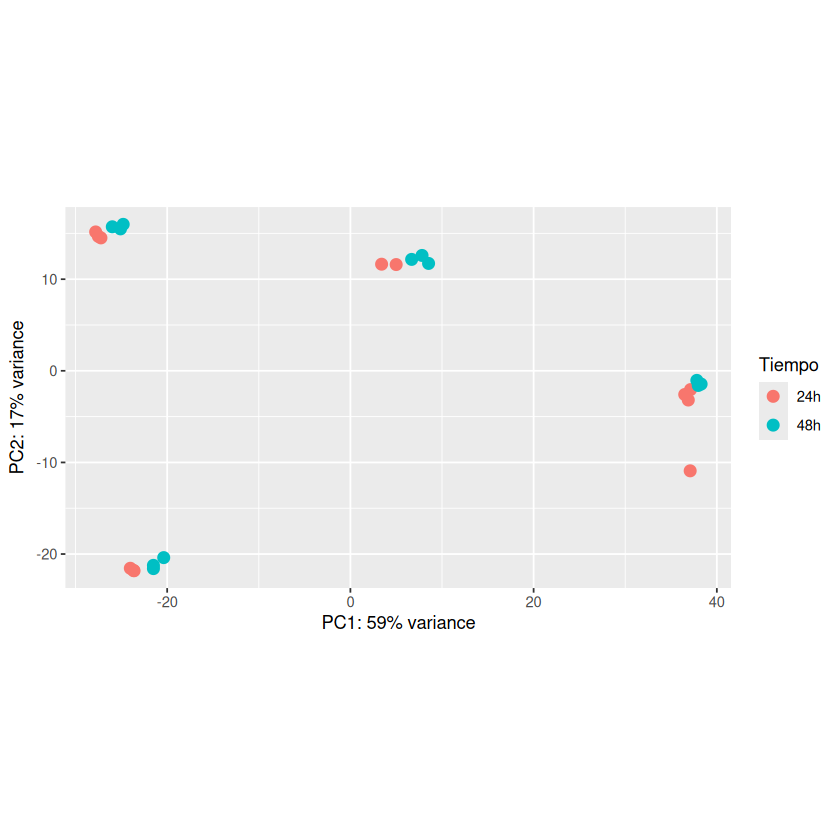

In [23]:
p <- plotPCA(vst_qc, intgroup = "time", returnData = FALSE)
p + labs(color = "Tiempo")

using ntop=500 top features by variance



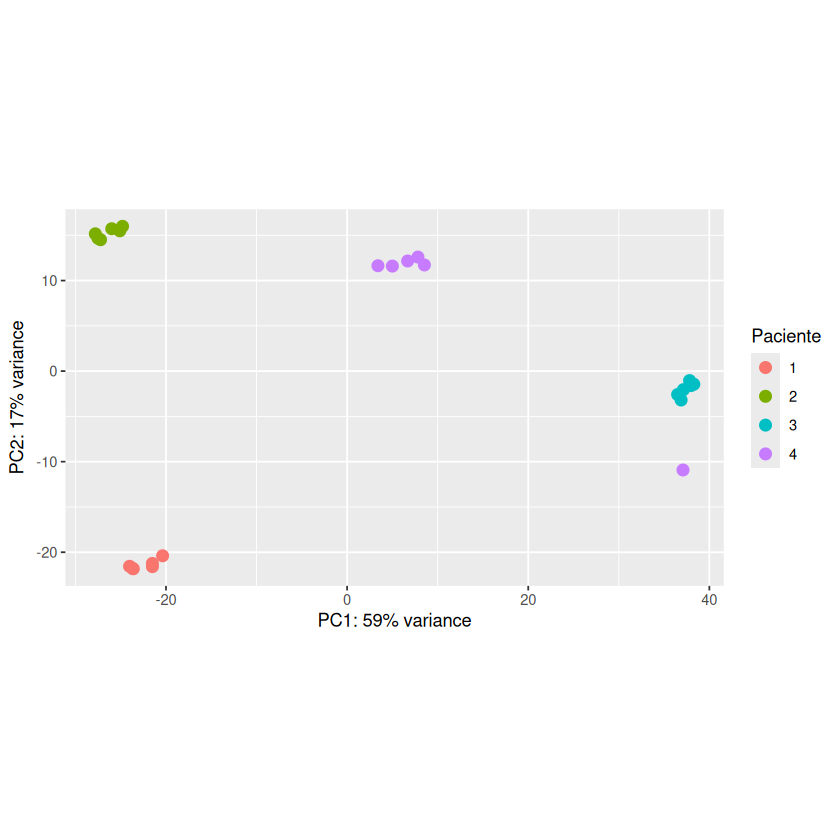

In [24]:
p <- plotPCA(vst_qc, intgroup = "patient", returnData = FALSE)
p + labs(color = "Paciente")

In [25]:
pca_df <- plotPCA(vst_qc, intgroup = "patient", returnData = TRUE)

# Coordenadas PC1 y PC2
head(pca_df[pca_df$group == "4", c("name", "group", "PC1", "PC2")])

# % de va

using ntop=500 top features by variance



,name,group,PC1,PC2
,<chr>,<fct>,<dbl>,<dbl>
GSM913891,GSM913891,4,7.821008,12.59194
GSM913892,GSM913892,4,3.406519,11.63614
GSM913893,GSM913893,4,6.685120,12.16061
GSM913894,GSM913894,4,4.997371,11.59760
GSM913895,GSM913895,4,8.533882,11.71986
GSM913896,GSM913896,4,37.089562,-10.91856


# Remove Errors

In [26]:
bad_sample <- "GSM913896"
metadata[bad_sample,]

,patient,agent,time
,<fct>,<fct>,<fct>
GSM913896,4,Control,24h


In [27]:
# Remove from DESeqDataSet
dds <- dds[, colnames(dds) != bad_sample]

# Keep metadata/counts aligned (if you still use these objects)
metadata <- metadata[rownames(metadata) != bad_sample, , drop = FALSE]
counts <- counts[, colnames(counts) != bad_sample, drop = FALSE]
dds

class: DESeqDataSet 
dim: 24416 23 
metadata(1): version
assays(4): counts mu H cooks
rownames(24416): ENSG00000000003 ENSG00000000005 ... ENSG00000257108
  ENSG00000257112
rowData names(43): gene baseMean ... deviance maxCooks
colnames(23): GSM913873 GSM913874 ... GSM913894 GSM913895
colData names(4): patient agent time sizeFactor

## Counts Plots

In [28]:
dim(vst_qc)

[1] 24416    24

In [29]:
vst_qc <- vst(dds, blind = TRUE) # Variance Stabilizing Transformation
vst_qc

class: DESeqTransform 
dim: 24416 23 
metadata(1): version
assays(1): ''
rownames(24416): ENSG00000000003 ENSG00000000005 ... ENSG00000257108
  ENSG00000257112
rowData names(43): gene baseMean ... maxCooks dispFit
colnames(23): GSM913873 GSM913874 ... GSM913894 GSM913895
colData names(4): patient agent time sizeFactor

In [30]:
## Calculamos las distancias a partir de las cuentas normalizadas y variance-stabilized (vst)
sampleDists <- dist(t(assay(vst_qc)))

head(sampleDists)

[1] 36.77718 29.90158 35.30464 28.04493 34.53942 70.88428

In [31]:
sampleDistMatrix <- as.matrix(sampleDists)
rownames(sampleDistMatrix) <- paste(vst_qc$patient, vst_qc$agent, vst_qc$time, sep="-")
colnames(sampleDistMatrix) <- paste(vst_qc$patient, vst_qc$agent, vst_qc$time, sep="-")

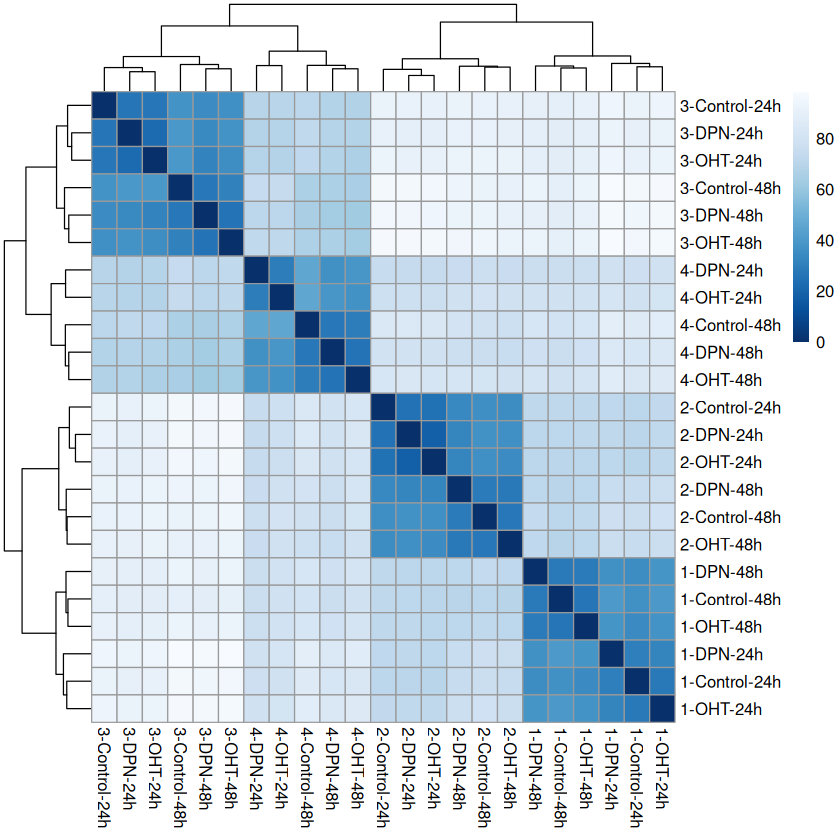

In [32]:
colors <- colorRampPalette( rev(brewer.pal(9, "Blues")) )(255)

pheatmap(sampleDistMatrix,
         clustering_distance_rows=sampleDists,
         clustering_distance_cols=sampleDists,
         col=colors)

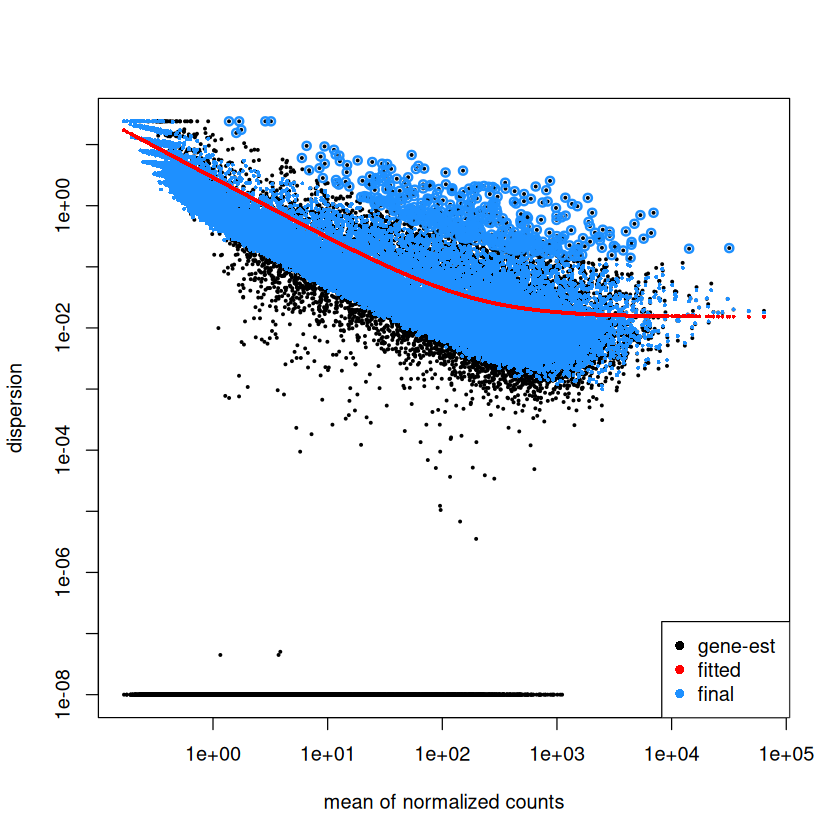

In [33]:
par( bg = "white")

## Vamos a verificar cómo ha quedado la estimación de la dispersión 
plotDispEsts(dds)

Warning message:
“Removed 121 rows containing non-finite outside the scale range
(`stat_binhex()`).”
Warning message:
“Removed 29 rows containing missing values or values outside the scale range
(`geom_hex()`).”


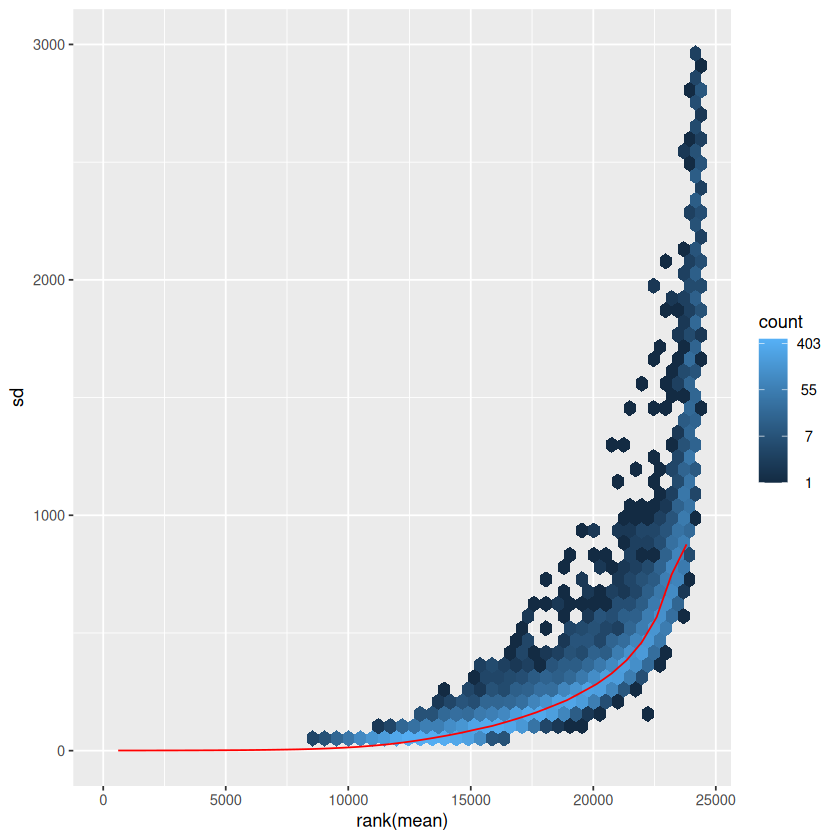

In [34]:
msd <- meanSdPlot(counts(dds), plot = FALSE)
msd$gg + ylim(0, 3000) ## Eliminamos los valores más altos sólo para la visualización

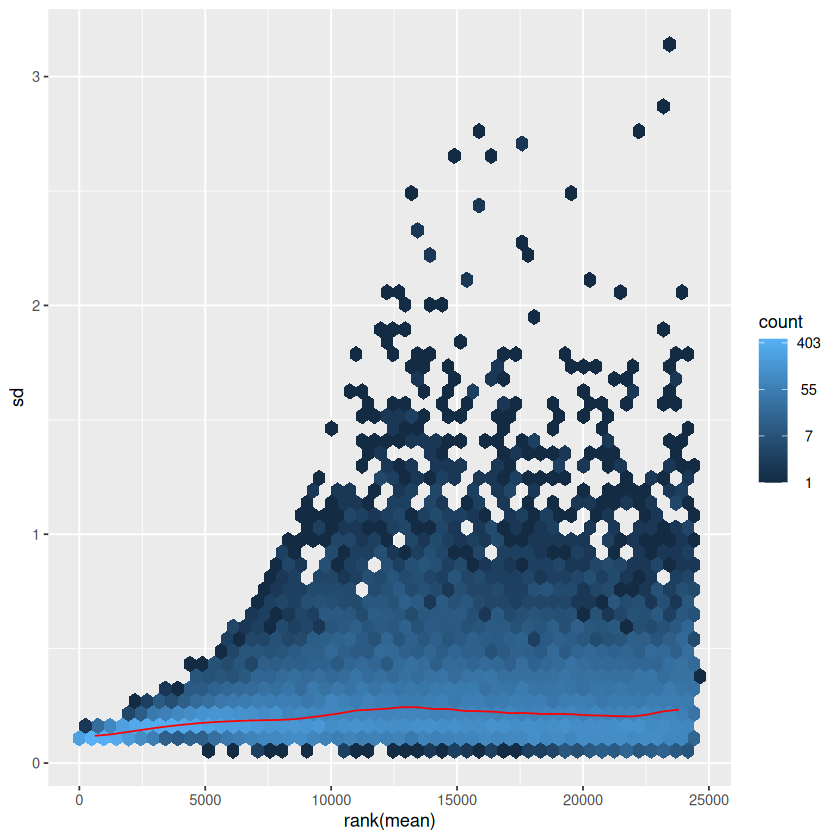

In [35]:
## Tras VST
par(bg = "white")

meanSdPlot(assay(vst_qc))

# DEA

In [36]:
metadata_24h <- subset(metadata, time == "24h")
counts_24h <- counts[, rownames(metadata_24h)]
dimensiones <- dim(counts_24h)

print(paste("Genes:", dimensiones[1], ", Muestras:", dimensiones[2]))

dds_dea <- DESeqDataSetFromMatrix(countData = counts_24h,
                               colData = metadata_24h,
                               design = ~ patient + agent)

[1] "Genes: 24416 , Muestras: 11"


In [37]:
dds_dea <- DESeq(dds_dea, test = "Wald")
dds_dea

estimating size factors

estimating dispersions

gene-wise dispersion estimates

mean-dispersion relationship

final dispersion estimates

fitting model and testing



class: DESeqDataSet 
dim: 24416 11 
metadata(1): version
assays(4): counts mu H cooks
rownames(24416): ENSG00000000003 ENSG00000000005 ... ENSG00000257108
  ENSG00000257112
rowData names(38): baseMean baseVar ... deviance maxCooks
colnames(11): GSM913873 GSM913875 ... GSM913892 GSM913894
colData names(4): patient agent time sizeFactor

In [38]:
##  blind = FALSE = Se recomienda para análisis posteriores, cuando quieres que la transformación respete los efectos biológicos o covariable
##  La transformación toma en cuenta el diseño design = ~ condition + batch

vst_dea <- vst(dds_dea, blind = FALSE) # Variance Stabilizing Transformation
vst_dea

class: DESeqTransform 
dim: 24416 11 
metadata(1): version
assays(1): ''
rownames(24416): ENSG00000000003 ENSG00000000005 ... ENSG00000257108
  ENSG00000257112
rowData names(38): baseMean baseVar ... maxCooks dispFit
colnames(11): GSM913873 GSM913875 ... GSM913892 GSM913894
colData names(4): patient agent time sizeFactor

## DPN vs Control

In [39]:
res_dpn <- results(object = dds_dea,
                      contrast = c("agent", "DPN", "Control"),
                      alpha = 0.05,
                      lfcThreshold = 0,#1,
                      pAdjustMethod = "BH",
                    )
res_dpn$gen <- rowData(dds)$gene[match(rownames(res_dpn), rownames(dds))]
res_dpn_df <- as.data.frame(res_dpn)

top_genes_dpn = head(order(res_dpn_df$padj), 10)
top_dpn = res_dpn_df[top_genes_dpn,]
top_dpn

,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj,gen
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>
ENSG00000044574,3664.6752,0.3663160,0.05975265,6.130540,8.758126e-10,5.214588e-06,HSPA5
ENSG00000100219,1937.1799,0.3299153,0.06649021,4.961863,6.982010e-07,8.314178e-04,XBP1
ENSG00000124406,2694.9466,0.3376607,0.06706317,5.034965,4.779368e-07,8.314178e-04,ATP8A1
ENSG00000138449,996.4967,0.3911514,0.07848301,4.983899,6.231561e-07,8.314178e-04,SLC40A1
ENSG00000166598,3979.2116,0.3003996,0.05958850,5.041235,4.625368e-07,8.314178e-04,HSP90B1
ENSG00000103335,3102.4652,-0.3431555,0.07086242,-4.842560,1.281770e-06,1.271943e-03,PIEZO1
ENSG00000127022,6354.6304,0.2550451,0.05391809,4.730232,2.242630e-06,1.907517e-03,CANX
ENSG00000113494,5338.8135,0.2773960,0.05966241,4.649427,3.328583e-06,2.477298e-03,PRLR
ENSG00000196924,8862.1863,-0.2737227,0.06027570,-4.541178,5.594073e-06,3.700790e-03,FLNA


In [40]:
print("DPN vs Control - Summary:")
summary(res_dpn)
summary(res_dpn_df)

[1] "DPN vs Control - Summary:"

out of 24411 with nonzero total read count
adjusted p-value < 0.05
LFC > 0 (up)       : 12, 0.049%
LFC < 0 (down)     : 20, 0.082%
outliers [1]       : 0, 0%
low counts [2]     : 18457, 76%
(mean count < 329)
[1] see 'cooksCutoff' argument of ?results
[2] see 'independentFiltering' argument of ?results



    baseMean        log2FoldChange          lfcSE              stat          
 Min.   :    0.00   Min.   :-4.040567   Min.   :0.04752   Min.   :-4.842560  
 1st Qu.:    2.69   1st Qu.:-0.142947   1st Qu.:0.11921   1st Qu.:-0.481364  
 Median :   47.74   Median : 0.001084   Median :0.28725   Median : 0.004570  
 Mean   :  315.77   Mean   : 0.011605   Mean   :0.83457   Mean   :-0.005772  
 3rd Qu.:  318.88   3rd Qu.: 0.153082   3rd Qu.:1.21138   3rd Qu.: 0.487888  
 Max.   :64110.68   Max.   : 4.266199   Max.   :4.11219   Max.   : 6.130540  
                    NA's   :5           NA's   :5         NA's   :5          
     pvalue            padj           gen           
 Min.   :0.0000   Min.   :0.000   Length:24416      
 1st Qu.:0.3794   1st Qu.:0.945   Class :character  
 Median :0.6278   Median :0.961   Mode  :character  
 Mean   :0.5912   Mean   :0.909                     
 3rd Qu.:0.8280   3rd Qu.:0.982                     
 Max.   :1.0000   Max.   :1.000                     
 NA's

In [41]:
sig_dpn <- sum(res_dpn$padj < 0.05, na.rm = TRUE)
print(paste("Significant genes (padj<0.05) - DPN:", sig_dpn))

[1] "Significant genes (padj<0.05) - DPN: 32"


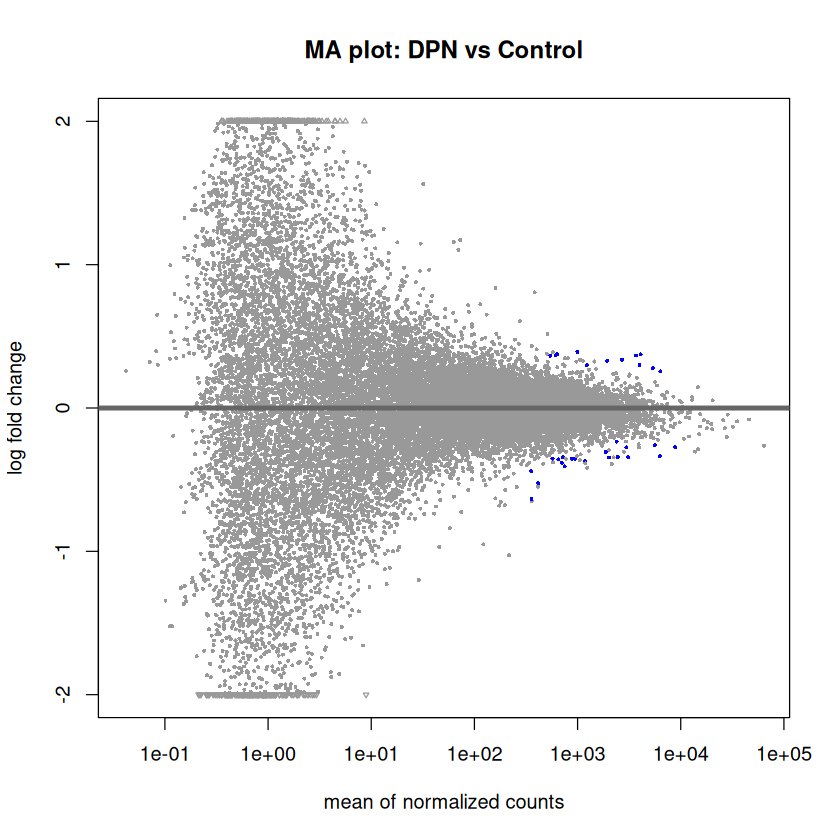

In [42]:
par(bg = "white")
plotMA(res_dpn, 
       main = "MA plot: DPN vs Control", 
       ylim = c(-2, 2))

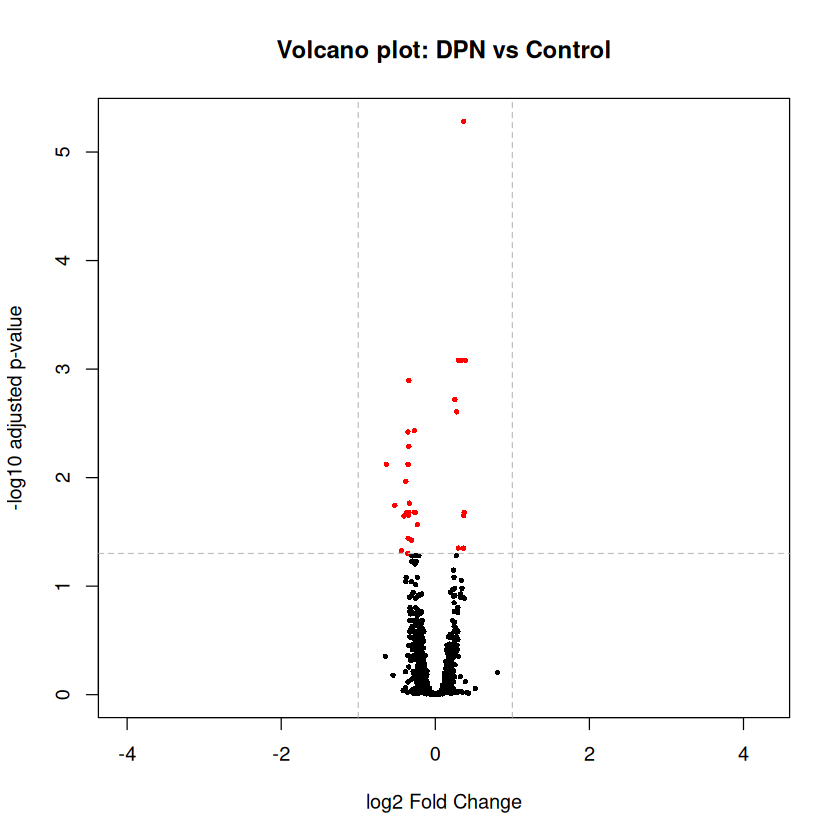

In [43]:
par(bg = "white")

# DPN vs Control volcano
plot(res_dpn$log2FoldChange, 
    -log10(res_dpn$padj), 
     main = "Volcano plot: DPN vs Control", 
     xlab = "log2 Fold Change", ylab = "-log10 adjusted p-value",
     pch = 16, col = ifelse(res_dpn$padj < 0.05, "red", "black"),
     cex = 0.6)
abline(v = c(-1, 1), h = -log10(0.05), lty = 2, col = "gray")

Warning message:
“Using `size` aesthetic for lines was deprecated in ggplot2 3.4.0.
ℹ Please use `linewidth` instead.
ℹ The deprecated feature was likely used in the EnhancedVolcano package.
  Please report the issue to the authors.”
Warning message:
“The `size` argument of `element_line()` is deprecated as of ggplot2 3.4.0.
ℹ Please use the `linewidth` argument instead.
ℹ The deprecated feature was likely used in the EnhancedVolcano package.
  Please report the issue to the authors.”


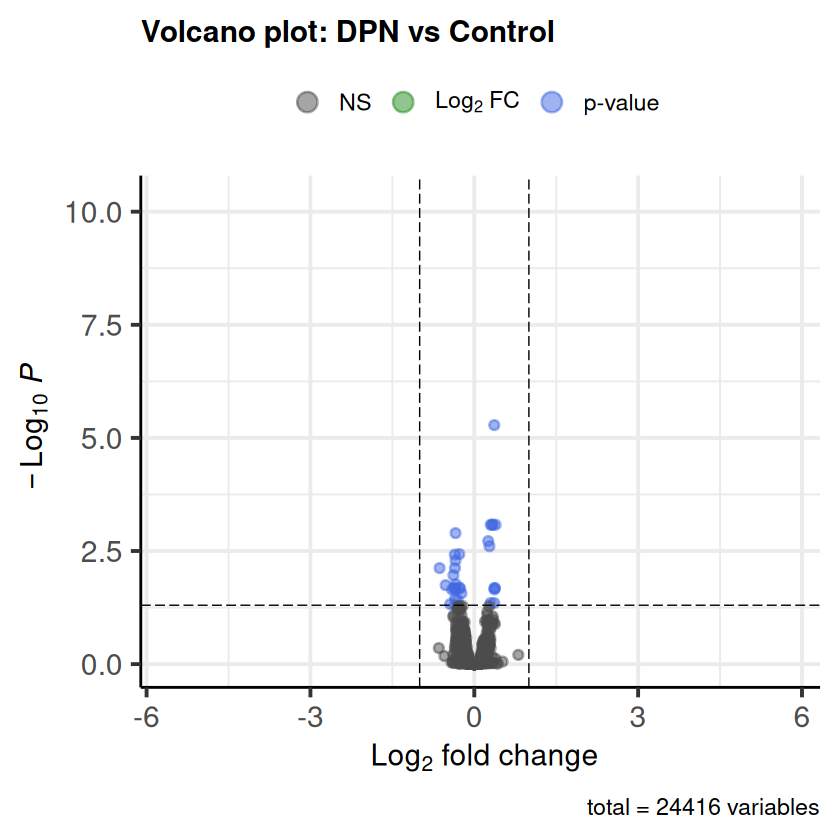

In [44]:
EnhancedVolcano(res_dpn_df,
                lab = res_dpn_df$gen,
                x = "log2FoldChange",
                y = "padj",
                title = "Volcano plot: DPN vs Control",
                FCcutoff = 1,
                pCutoff = 0.05,
                subtitle = NULL,
                boxedLabels = TRUE,
                drawConnectors = TRUE,
                labSize = 6.0)

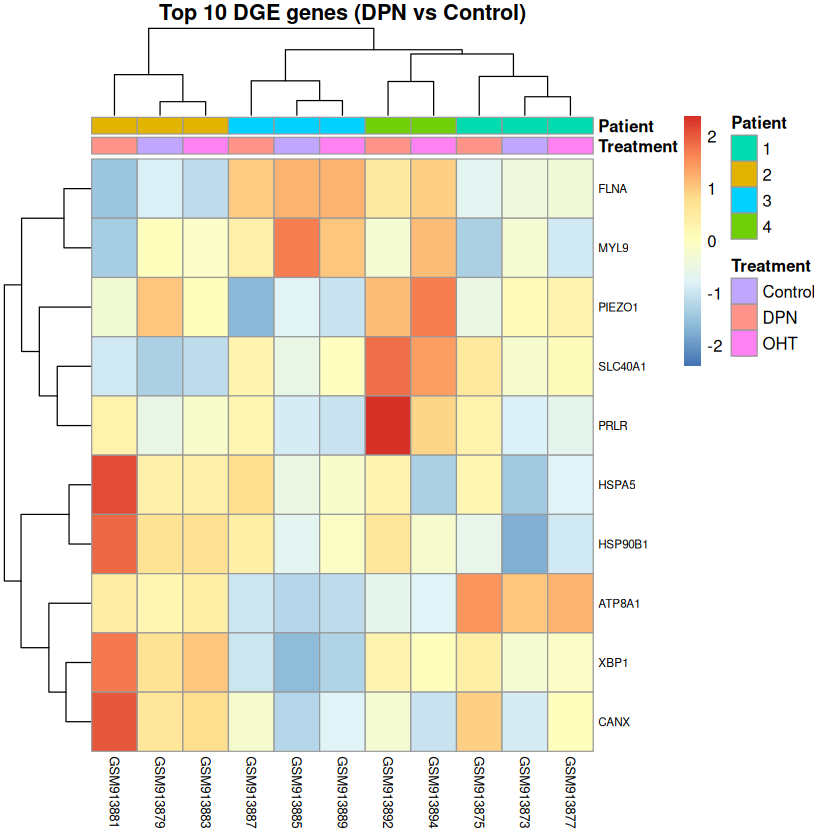

In [45]:
# Heatmap of top differentially expressed genes

vst_counts <- assay(vst_dea)[top_genes_dpn, ]

rownames(vst_counts) <- gene_labels[top_genes_dpn]
anno <- data.frame(Treatment = metadata$agent, 
                    #Time = metadata$time, 
                    Patient = metadata$patient)
rownames(anno) <- rownames(metadata)

pheatmap(vst_counts, 
         annotation_col = anno,
         main = "Top 10 DGE genes (DPN vs Control)",
         fontsize_row = 7,
         fontsize_col = 8,
         scale = "row",
         show_colnames = TRUE) 

In [46]:
sig_genes_dpn <- res_dpn_df[which(res_dpn_df$padj < 0.05), ]
top_genes_dpn <- sig_genes_dpn[which(abs(sig_genes_dpn$log2FoldChange) > 1), ]
top_genes_dpn

baseMean,log2FoldChange,lfcSE,stat,pvalue,padj,gen
<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>


In [47]:
first_gene_dpn <- rownames(sig_genes_dpn)[1]
first_gene_dpn_label <- gene_labels[first_gene_dpn]
print(paste(first_gene_dpn, "---", first_gene_dpn_label))

[1] "ENSG00000006327 --- TNFRSF12A"


In [48]:
gene_distribution[first_gene_dpn, ]

,mean,median,variance,sd,min,max,zero_fraction
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
ENSG00000006327,2376.889,2245.121,283543.4,532.488,1533.712,3522.755,0


In [49]:
norm_counts[first_gene_dpn, ]

GSM913873 GSM913874 GSM913875 GSM913876 GSM913877 GSM913878 GSM913879 GSM913880 
 2226.250  1533.712  1925.179  1569.377  2134.914  1647.910  2263.992  2022.139 
GSM913881 GSM913882 GSM913883 GSM913884 GSM913885 GSM913886 GSM913887 GSM913888 
 1850.612  2046.828  2129.865  2221.376  2656.888  2663.122  2372.431  2602.891 
GSM913889 GSM913890 GSM913891 GSM913892 GSM913893 GSM913894 GSM913895 GSM913896 
 2572.929  2924.420  3172.946  2942.452  2636.124  3522.755  3266.939  2139.285

In [50]:
df_first_gene_dpn <- data.frame(
  NormalizedCount = as.numeric(norm_counts[first_gene_dpn, ]),
  Agent = metadata[colnames(norm_counts), "agent"]
)
head(df_first_gene_dpn)

,NormalizedCount,Agent
,<dbl>,<fct>
1,2226.250,Control
2,1533.712,Control
3,1925.179,DPN
4,1569.377,DPN
5,2134.914,OHT
6,1647.910,OHT


In [51]:
df_first_gene_dpn <- subset(df_first_gene_dpn, Agent != "OHT")
df_first_gene_dpn

,NormalizedCount,Agent
,<dbl>,<fct>
1,2226.250,Control
2,1533.712,Control
3,1925.179,DPN
4,1569.377,DPN
7,2263.992,Control
8,2022.139,Control
9,1850.612,DPN
10,2046.828,DPN
13,2656.888,Control


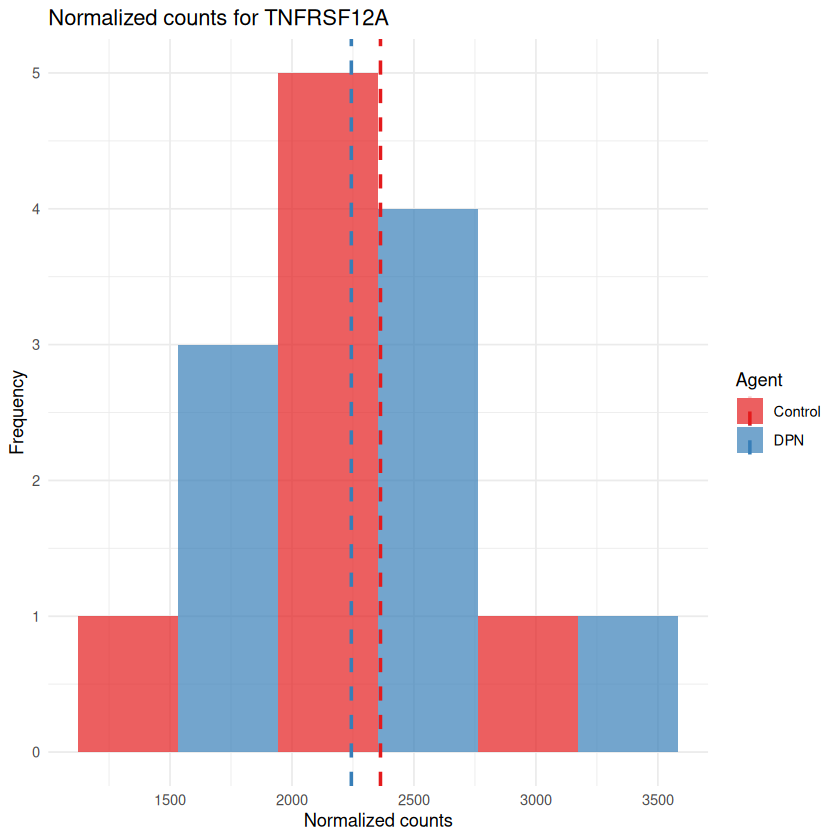

In [52]:
means <- aggregate(NormalizedCount ~ Agent, data = df_first_gene_dpn, mean)

ggplot(df_first_gene_dpn, aes(x = NormalizedCount, fill = Agent)) +
  geom_histogram(position = "dodge", alpha = 0.7, bins = 3) +
  geom_vline(
    data = means,
    aes(xintercept = NormalizedCount, color = Agent),
    linetype = "dashed", size = 1
  ) +
  labs(
    title = paste("Normalized counts for", first_gene_dpn_label),
    x = "Normalized counts", y = "Frequency"
  ) +
  theme_minimal() +
  scale_fill_brewer(palette = "Set1") +
  scale_color_brewer(palette = "Set1")

## OHT vs Control

In [53]:
## Obtengamos nuestra lista de genes DEG
res_oht <- results(object = dds_dea,
                      contrast = c("agent", "OHT", "Control"),
                      alpha = 0.05,
                      lfcThreshold = 0,
                      pAdjustMethod = "BH",
                      #tidy = TRUE
                    )
res_oht$gen <- rowData(dds)$gene[match(rownames(res_oht), rownames(dds))]
res_oht_df <- as.data.frame(res_oht)

top_genes_oht = head(order(res_oht_df$padj), 10)
top_oht = res_oht_df[top_genes_oht,]
top_oht

,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj,gen
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>
ENSG00000131462,3.916659e+02,0.4921181,0.11005508,4.471562,7.765037e-06,0.04738808,TUBG1
ENSG00000135447,1.794746e+02,-0.8219376,0.18160297,-4.526014,6.010659e-06,0.04738808,PPP1R1A
ENSG00000183648,1.743603e+02,-0.8192224,0.18224486,-4.495174,6.951301e-06,0.04738808,NDUFB1
ENSG00000232912,2.691361e-01,-18.5616118,4.11135185,-4.514722,6.339979e-06,0.04738808,RERE-AS1
ENSG00000111640,3.522804e+02,-0.4701575,0.11254117,-4.177649,2.945381e-05,0.12560737,GAPDH
ENSG00000149806,1.615087e+02,-0.7875292,0.18899513,-4.166928,3.087314e-05,0.12560737,FAU
ENSG00000188707,1.204917e+04,-0.3301246,0.08122034,-4.064555,4.812409e-05,0.16782244,ZBED10P
ENSG00000184110,1.055308e+03,0.4002319,0.09934599,4.028667,5.609412e-05,0.16909314,EIF3C
ENSG00000184897,5.233989e+02,-0.3698096,0.09236547,-4.003765,6.234232e-05,0.16909314,H1-10


In [54]:
print("\nOHT vs Control - Summary:")
summary(res_oht)
summary(res_oht_df)

[1] "\nOHT vs Control - Summary:"



out of 24411 with nonzero total read count
adjusted p-value < 0.05
LFC > 0 (up)       : 1, 0.0041%
LFC < 0 (down)     : 3, 0.012%
outliers [1]       : 0, 0%
low counts [2]     : 0, 0%
(mean count < 0)
[1] see 'cooksCutoff' argument of ?results
[2] see 'independentFiltering' argument of ?results



    baseMean        log2FoldChange          lfcSE              stat         
 Min.   :    0.00   Min.   :-18.56161   Min.   :0.04745   Min.   :-4.52601  
 1st Qu.:    2.69   1st Qu.: -0.12274   1st Qu.:0.11800   1st Qu.:-0.41256  
 Median :   47.74   Median :  0.01583   Median :0.28438   Median : 0.06340  
 Mean   :  315.77   Mean   :  0.03520   Mean   :0.82750   Mean   : 0.04194  
 3rd Qu.:  318.88   3rd Qu.:  0.16726   3rd Qu.:1.19356   3rd Qu.: 0.53063  
 Max.   :64110.68   Max.   :  3.70634   Max.   :4.11219   Max.   : 4.47156  
                    NA's   :5           NA's   :5         NA's   :5         
     pvalue              padj             gen           
 Min.   :0.000006   Min.   :0.04739   Length:24416      
 1st Qu.:0.385802   1st Qu.:1.00000   Class :character  
 Median :0.637871   Median :1.00000   Mode  :character  
 Mean   :0.597199   Mean   :0.99858                     
 3rd Qu.:0.831680   3rd Qu.:1.00000                     
 Max.   :1.000000   Max.   :1.00000       

In [55]:
sig_oht <- sum(res_oht_df$padj < 0.05, na.rm = TRUE)
print(paste("Significant genes (padj<0.05) - OHT:", sig_oht))

[1] "Significant genes (padj<0.05) - OHT: 4"


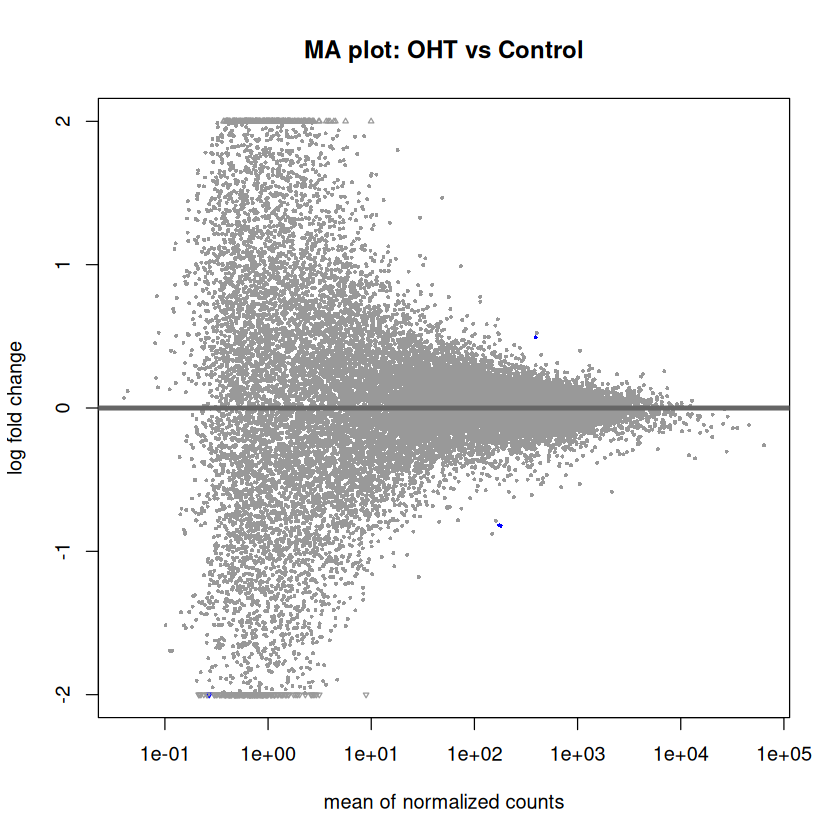

In [56]:
# Create MA plots
par( bg = "white")
plotMA(res_oht, 
       main = "MA plot: OHT vs Control",
       ylim = c(-2, 2))

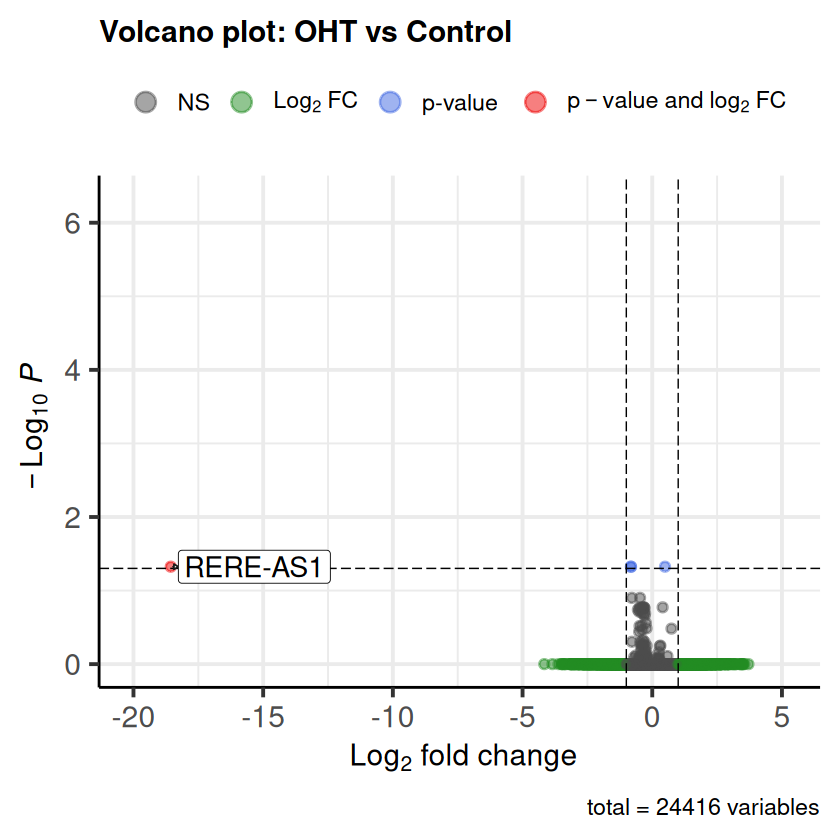

In [57]:
EnhancedVolcano(res_oht_df,
                lab = res_oht_df$gen,
                x = "log2FoldChange",
                y = "padj",
                title = "Volcano plot: OHT vs Control",
                FCcutoff = 1,
                pCutoff = 0.05,
                subtitle = NULL,
                boxedLabels = TRUE,
                drawConnectors = TRUE,
                labSize = 6.0)

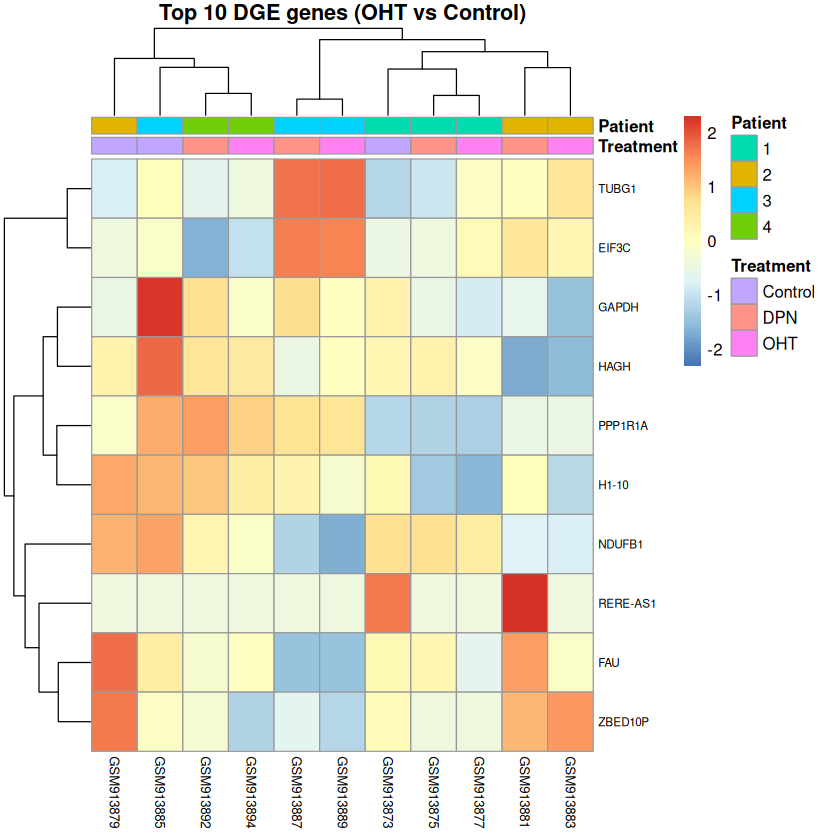

In [58]:
# Heatmap of top differentially expressed genes

vst_counts <- assay(vst_dea)[top_genes_oht, ]

rownames(vst_counts) <- gene_labels[top_genes_oht]
anno <- data.frame(Treatment = metadata$agent, 
                    #Time = metadata$time, 
                    Patient = metadata$patient)
rownames(anno) <- rownames(metadata)

pheatmap(vst_counts, 
         annotation_col = anno,
         main = "Top 10 DGE genes (OHT vs Control)",
         fontsize_row = 7,
         fontsize_col = 8,
         scale = "row",
         show_colnames = TRUE) 

In [59]:
sig_genes_oht <- res_oht_df[which(res_oht_df$padj < 0.05), ]
top_genes_oht <- sig_genes_oht[which(abs(sig_genes_oht$log2FoldChange) > 1), ]
top_genes_oht

,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj,gen
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>
ENSG00000232912,0.2691361,-18.56161,4.111352,-4.514722,6.339979e-06,0.04738808,RERE-AS1


In [60]:
first_gene_oht <- rownames(top_genes_oht)[1]
first_gene_oht_label <- gene_labels[first_gene]
print(paste(first_gene_oht, "---", first_gene_oht_label))

ERROR: Error: objeto 'first_gene' no encontrado


In [ ]:
df_first_gene_oht <- data.frame(
  NormalizedCount = as.numeric(norm_counts[first_gene_oht, ]),
  Agent = metadata[colnames(norm_counts), "agent"]
)
head(df_first_gene_oht)

,NormalizedCount,Agent
,<dbl>,<fct>
1,1.131799,Control
2,0.000000,Control
3,0.000000,DPN
4,1.064707,DPN
5,0.000000,OHT
6,0.000000,OHT


In [ ]:
df_first_gene_oht <- subset(df_first_gene_oht, Agent != "DPN")
df_first_gene_oht

,NormalizedCount,Agent
,<dbl>,<fct>
1,1.131799,Control
2,0.000000,Control
5,0.000000,OHT
6,0.000000,OHT
7,0.000000,Control
8,0.000000,Control
11,0.000000,OHT
12,3.901715,OHT
13,0.000000,Control


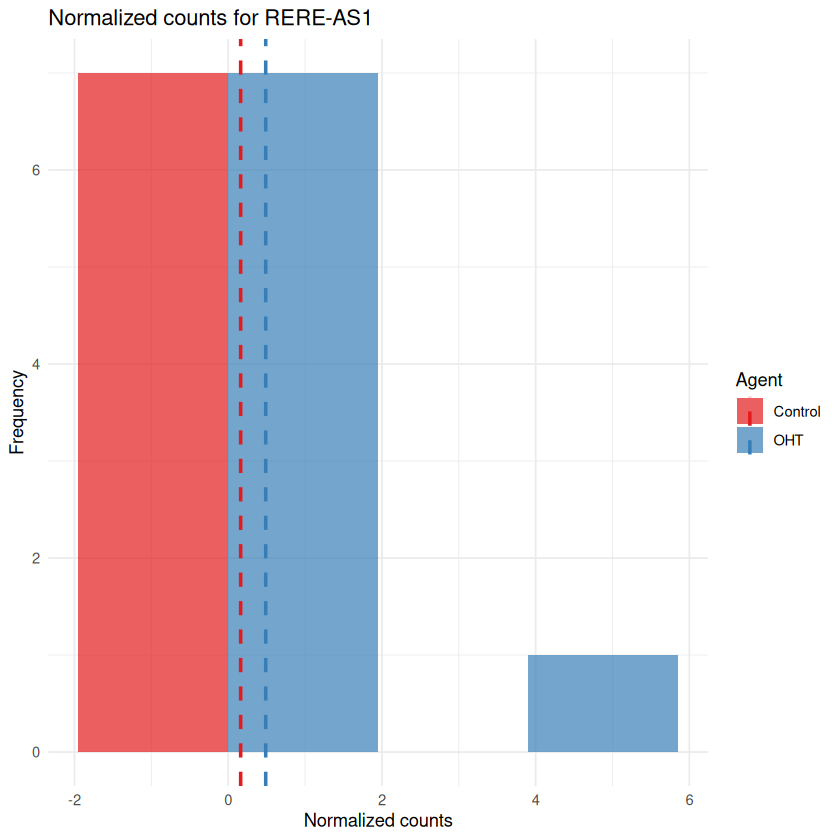

In [ ]:
means <- aggregate(NormalizedCount ~ Agent, data = df_first_gene_oht, mean)

ggplot(df_first_gene_oht, aes(x = NormalizedCount, fill = Agent)) +
  geom_histogram(position = "dodge", alpha = 0.7, bins = 2) +
  geom_vline(
    data = means,
    aes(xintercept = NormalizedCount, color = Agent),
    linetype = "dashed", size = 1
  ) +
  labs(
    title = paste("Normalized counts for", first_gene_oht_label),
    x = "Normalized counts", y = "Frequency"
  ) +
  theme_minimal() +
  scale_fill_brewer(palette = "Set1") +
  scale_color_brewer(palette = "Set1")

## Save results

In [64]:
saveRDS(dds_dea, file = "Apartado2/output/dds.rds")
saveRDS(metadata_24h, file = "Apartado2/output/metadata_dds.rds")